<a href="https://colab.research.google.com/github/Rupa20052003/CODSOFT/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np  #linear algebra
import pandas as pd   #data processing

import os

import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder

In [38]:
employee= pd.read_csv("/content/churn.csv")

In [39]:
employee.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer,42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
employee = employee.drop(['customerID'] , axis=1)
employee.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
employee.TotalCharges.value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [11]:
employee['TotalCharges'] = employee["TotalCharges"].replace(" ",np.nan ).astype(float)

In [12]:
employee.TotalCharges.value_counts(dropna=False)

,count
TotalCharges,
NaN,11
20.20,11
19.75,9
20.05,8
19.90,8
...,...
130.15,1
3211.90,1
7843.55,1


In [13]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


#Do we has na in data

In [14]:
employee.isna().sum()  #is=check & as=convert

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [15]:
employee.TotalCharges.fillna(employee.TotalCharges.mean(), inplace=True)  #one column of na time

In [16]:
employee.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Outlier

<Axes: ylabel='TotalCharges'>

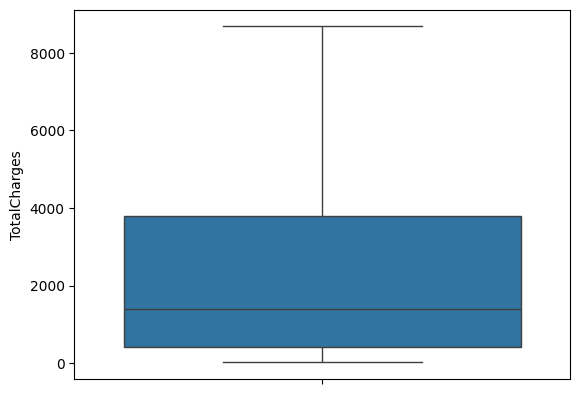

In [17]:
import seaborn as sns
sns.boxplot(data=employee.TotalCharges)

In [19]:
employee.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer,42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card,89.10,1949.40,No
7,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,No,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer,56.15,3487.95,No


In [20]:
employee.OnlineSecurity.value_counts(ascending=False)

,count
OnlineSecurity,
No,3498
Yes,2019
No internet service,1526


In [21]:
employee.OnlineSecurity =employee.OnlineSecurity.replace({"No internet service":"No"})

In [22]:
employee.OnlineSecurity.value_counts()

,count
OnlineSecurity,
No,5024
Yes,2019


In [25]:
employee.OnlineBackup =employee.OnlineBackup.replace({"No internet service":"No"})
employee.DeviceProtection =employee.DeviceProtection.replace({"No internet service":"No"})
employee.TechSupport =employee.TechSupport.replace({"No internet service":"No"})
employee.StreamingTV =employee.StreamingTV.replace({"No internet service":"No"})
employee.StreamingMovies=employee.StreamingMovies.replace({"No internet service":"No"})
employee.MultipleLines =employee.MultipleLines.replace({"No internet service":"No"})



In [27]:
employee.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869


In [29]:
import plotly.express as px

fig=px.pie(employee,names='Churn' , color='Churn' , color_discrete_map={'Yes':'red' ,'No':'green'})
fig.show()

In [30]:
employee.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869


Trend Analysis

In [31]:
Churn_Customer =employee.loc[employee['Churn'] == 'Yes']
Churn_Customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,Male,No,No,No,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer,103.70,5036.30,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7021,Male,No,No,No,12,Yes,No,DSL,No,No,No,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes
7026,Female,No,No,No,9,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer,44.20,403.35,Yes
7032,Male,Yes,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7034,Female,No,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card,102.95,6886.25,Yes


In [32]:
fig=px.sunburst(Churn_Customer , path=["SeniorCitizen" ,"InternetService" , "Contract" , "PaymentMethod"])
fig.show()

In [33]:
employee_num =employee.select_dtypes(include=[np.number])
employee_num.head(3)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15


In [34]:
employee_dummies = employee.select_dtypes(include=['object'])
employee_dummies.head(3)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [37]:
employee_dummies =employee_dummies.apply(LabelEncoder().fit_transform)
employee_dummies.head(3)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,2,0
1,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,3,0
2,1,0,0,0,1,0,0,1,1,0,0,0,0,0,1,3,1


In [44]:
from sklearn.preprocessing import LabelEncoder
employee_dummies=employee_dummies.apply(LabelEncoder().fit_transform)
employee_dummies.head(3)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,2,0
1,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,3,0
2,1,0,0,0,1,0,0,1,1,0,0,0,0,0,1,3,1


In [45]:
employee_combined = pd.concat([employee_num, employee_dummies], axis=1)
employee_combined.head()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,1,29.85,29.85,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,2,0
1,34,56.95,1889.50,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,3,0
2,2,53.85,108.15,1,0,0,0,1,0,0,1,1,0,0,0,0,0,1,3,1
3,45,42.30,1840.75,1,0,0,0,0,1,0,1,0,1,1,0,0,1,0,0,0
4,2,70.70,151.65,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


In [47]:
from sklearn.model_selection import train_test_split

#Define or input vairable (x) & output variable
X = employee_combined.drop('Churn',axis=1)
y = employee_combined['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=231)

Model Building

In [50]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [52]:
train = pd.concat([y_train,X_train] ,axis=1)
train.head()

,Churn,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
1583,0,6,48.95,273.25,0,0,1,1,1,2,0,0,0,0,0,0,0,0,1,1
6791,1,19,39.65,733.35,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,2
4812,1,9,66.25,620.55,0,0,0,0,1,0,0,0,1,0,1,1,0,0,0,3
6282,0,4,19.55,68.80,1,0,1,1,1,0,2,0,0,0,0,0,0,2,0,1
2479,0,56,75.85,4261.20,1,0,1,1,1,2,0,1,1,0,1,0,1,2,1,1


In [53]:
independent_variable =list(train.columns[1:])
independent_variable

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10]})

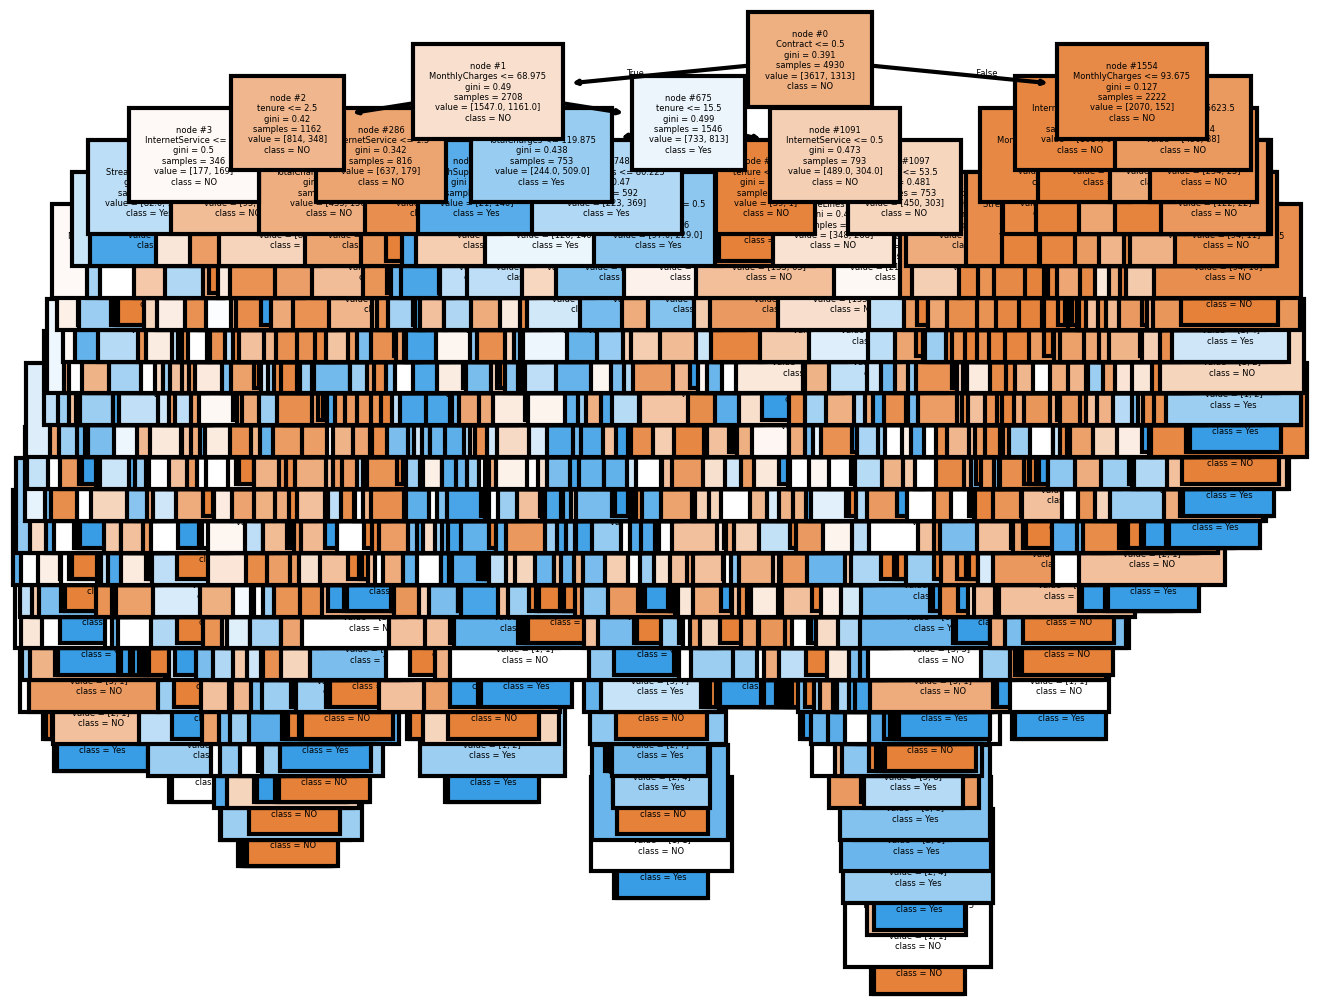

In [55]:
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

churn =['NO' , 'Yes']
fig , axes = plt.subplots(nrows = 1 , ncols = 1 , figsize = (5,4) , dpi = 300)
tree.plot_tree(dt, #model
               feature_names = independent_variable , #column name
               class_names=churn, # Yes no
               filled = True , #colour
               node_ids=True, #node number
               fontsize=2);  # fig.save

# Define param_grid for GridSearchCV
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(dt, param_grid, cv=5)
grid_search.fit(X,y)